In [1]:
from latent_dubins_gap_nogp import LatentDubinGapNoGP, get_args, state_to_image_pil_hq
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from colorama import Fore, Back, Style
import matplotlib.colors as mcolors

class DubinEnv():
    def __init__(self, start_state, goal_state):
        self.start_state = start_state
        self.curr_state = start_state
        self.goal_state = goal_state
        self.args = get_args()
        self.v = self.args.speed
        self.dt = self.args.dt

    def forward(self, action):
        # Apply the action to the current state
        state_obs, img_obs, state_gt, dones, acs = ([] for _ in range(5))
        pstate = self.curr_state.copy()
        pstate[0] += self.v * np.cos(self.curr_state[2]) * self.dt
        pstate[1] += self.v * np.sin(self.curr_state[2]) * self.dt
        pstate[2] += action * self.dt  # Update the heading angle
        img = state_to_image_pil_hq(pstate, self.args)

        state_obs.append(pstate[2]) # get to observe theta
        state_gt.append(pstate) # gt state
        dones.append(1)
        acs.append(action)
        img_obs.append(img)

        demo = {}
        demo['obs'] = {'image': img_obs, 'state': state_obs, 'priv_state': state_gt}
        demo['actions'] = acs
        demo['dones'] = dones
        return demo, pstate
    
    def goal_ref(self):
        # Calculate the direction towards the goal
        dx = self.goal_state[0] - self.curr_state[0]
        dy = self.goal_state[1] - self.curr_state[1]
        angle_to_goal = np.arctan2(dy, dx)
        ref_theta = angle_to_goal
        delta_theta = ref_theta - self.curr_state[2]
        # Normalize the angle to be within [-pi, pi] using modulo operation
        delta_theta = (delta_theta + np.pi) % (2 * np.pi) - np.pi
        ref_theta_dot = (delta_theta) / self.dt

        return ref_theta, np.clip(ref_theta_dot, -self.args.turnRate, self.args.turnRate)

to_np = lambda x: x.cpu().detach().numpy()

/home/clown2/Desktop/Work/Research/wm_cbf


## CBF on Latent Dubins

Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}
Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
Optimizer model_opt has 27002886 variables.
No valid actions found, using goal action.
Step 1: Pstate: [-1.3   1.2  -1.51], Goal: -0.5, Action: 1.25, Dist: 2.59, Safe Value: 0.8600000143051147
No valid actions found, using goal action.
Step 2: Pstate: [-1.3   1.15 -1.45], Goal: -0.48, Action: 1.25, Dist: 2.57, Safe Value: 0.8600000143051147
No valid actions found, using goal action.
Step 3: Pstate: [-1.29  1.1  -1.38], Goal: -0.46, Action: 1.25, Dist: 2.54, Safe Value: 0.8600000143051147
Closest action index: 99, Value: 0.9618520140647888, Goal Action: 1.25
Step 4: Pstate: [-1.28  1.05 -1.32], Goal: -0.45, Action: 1.2200000286102295, Dist: 2.51, Safe Value: 0.8700000047683716
No valid actions found, using goal action.
Step 5: Pstate: [-1.27  1.   -1.26], Goal: -0.43, Action: 1.25, Dist: 2.48, Safe Value: 0.870000004768

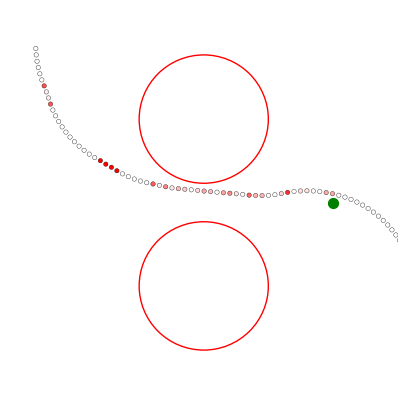

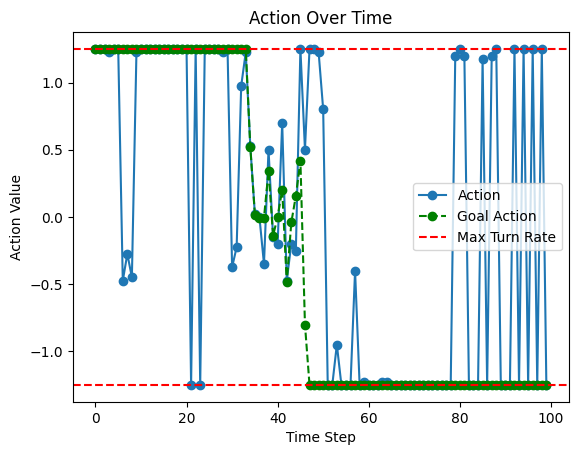

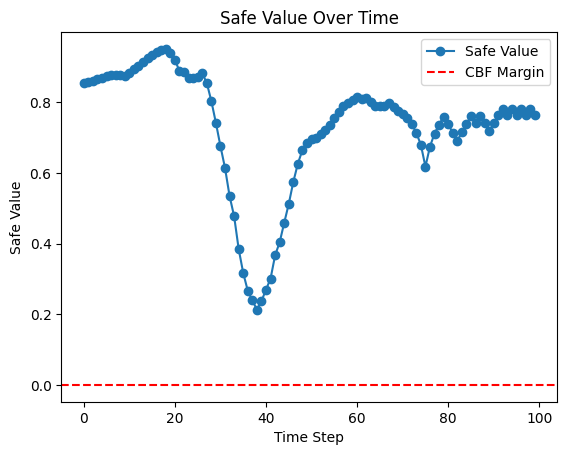

In [22]:
dubin_env = DubinEnv(start_state=np.array([-1.3, 1.3, -np.pi/2]),
                     goal_state=np.array([1, 0, 0.0]))

brt = LatentDubinGapNoGP()

priv_states = []
actions = []
goal_actions = []
current_safe = []
safe_values = []

gamma = 1
simlen = 100
u_min = -dubin_env.args.turnRate
u_max = dubin_env.args.turnRate
u_samples = 100
u_delta = (u_max - u_min) / u_samples
u_range = np.arange(u_min, u_max + u_delta, u_delta)  # action range for Dubins car
u_range = torch.tensor(u_range, dtype=torch.float32, device=brt.args.device).unsqueeze(-1)  # Convert to tensor

demo, priv_state = dubin_env.forward(0) # initialize with zero action
feat = brt.data_to_feat(demo)           # render state (took another step in wm)
Vz = brt.evaluate_V(to_np(feat))[0]
Lz = brt.margin_fn(feat)[0][0][0]
safe_value = np.min([Vz, to_np(Lz)])  
demo, priv_state = dubin_env.forward(0) # take real step to match wm step
dubin_env.curr_state = priv_state       # take another step in real
# at this point, Vz should indicate value of current state 

for i in range(simlen):
    # get goal reference direction and action
    goal_dir, goal_act = dubin_env.goal_ref()
    curr_safe = 1 

    Qzs = brt.evaluate_Q(to_np(feat), u_range)
    # print(f"Qzs: {Qzs}")
    cbf_cond = Qzs > gamma * Vz
    # print(f"CBF Condition: {cbf_cond}")
    Qzs_valid_idx = np.where(cbf_cond)[0]
    # print(f"u_range: {u_range.squeeze(-1).detach().cpu().numpy()}")

    if Qzs_valid_idx.size == 0:
        print(Fore.RED + "No valid actions found, using goal action."+Style.RESET_ALL)
        action = goal_act
    else:
        # Find the action that maximizes the Q-value while satisfying the CBF condition
        Qzs_valid = Qzs[Qzs_valid_idx]
        # Find the action that minimizes the distance to the goal action
        affordable_actions = torch.abs(u_range.squeeze(-1).masked_fill(torch.tensor(~cbf_cond, device=u_range.device), torch.inf) - goal_act)
        # print(f"Affordable actions: {affordable_actions}")
        closest_action = torch.argmin(affordable_actions)
        print(f"Closest action index: {closest_action}, Value: {Qzs[closest_action]}, Goal Action: {goal_act}")
        action = u_range[closest_action][0].detach().cpu().numpy()

    feat = brt.data_to_feat(demo, action=action) # take action in wm
    demo, priv_state = dubin_env.forward(action) # take action in real
    Vz = brt.evaluate_V(to_np(feat))[0] # Vz after action
    Lz = brt.margin_fn(feat)[0][0][0]
    safe_value = np.min([Vz, to_np(Lz)])   
    dubin_env.curr_state = priv_state  # update state after taking action

    priv_states.append(priv_state)
    actions.append(action)
    goal_actions.append(goal_act)
    current_safe.append(curr_safe)
    safe_values.append(safe_value)

    distance = np.linalg.norm(dubin_env.goal_state[:2] - dubin_env.curr_state[:2])
    print(f"Step {i+1}: Pstate: {np.round(priv_state,2)}, "
          f"Goal: {np.round(goal_dir,2)}, "
          f"Action: {np.around(action,2)}, "
          f"Dist: {np.round(distance,2)}, "
          f"Safe Value: {np.round(safe_value, 2)}")
    
    if distance < 0.05:
        print("Reached the goal!")
        break

# plot: black edge for trajectory points, red for intervention
# plot: white to red gradient for delta action magnitude
delta_action = np.abs(np.diff(np.array(actions), prepend=actions[0]))
colors = ["white", "red"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("white_red", colors)
norm = mcolors.Normalize(vmin=0, vmax=u_max - u_min)

# plot the trajectory history and circle obstacle
fig, ax = plt.subplots()
# hardcoded with existing limits
sf = 1 # scale factor
plt.xlim([sf*brt.args.x_min, sf*brt.args.x_max])
plt.ylim([sf*brt.args.y_min, sf*brt.args.y_max])
plt.axis('off')
fig.set_size_inches(5, 5)
pss = np.array(priv_states)

for x_obs, y_obs, r_obs in zip(brt.args.obs_x, brt.args.obs_y, brt.args.obs_r):
    circle = patches.Circle((x_obs, y_obs), r_obs, edgecolor=(1,0,0), facecolor='none')
    ax.add_patch(circle)

plt.scatter(pss[:,0], pss[:,1], c=delta_action, s=10, label='Trajectory', cmap=custom_cmap, norm=norm, edgecolor='black', linewidth=0.25)
plt.scatter(dubin_env.goal_state[0], dubin_env.goal_state[1], c='green', s=50, label='Goal')

# plot action over time
plt.figure()
plt.plot(np.array(actions), label='Action', marker='o')
plt.plot(np.array(goal_actions), label='Goal Action', marker='o', linestyle='--', color='green')
plt.axhline(y=dubin_env.args.turnRate, color='r', linestyle='--', label='Max Turn Rate')
plt.axhline(y=-dubin_env.args.turnRate, color='r', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Action Value')
plt.title('Action Over Time')
plt.legend()
plt.show()

# plot safe value over time
plt.figure()
plt.plot(safe_values, label='Safe Value', marker='o')
plt.axhline(y=0, color='r', linestyle='--', label='CBF Margin')
plt.xlabel('Time Step')
plt.ylabel('Safe Value')
plt.title('Safe Value Over Time')
plt.legend()
plt.show()


## LRSF on Latent Dubins

Encoder CNN shapes: {'image': (128, 128, 3)}
Encoder MLP shapes: {'obs_state': (2,)}
Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
Optimizer model_opt has 27002886 variables.
Step 1: Pstate: [-1.3   1.2  -1.51], Goal: -0.5, Action: 1.25, Dist: 2.59, Safe Value: 0.8550000190734863
Step 2: Pstate: [-1.3   1.15 -1.45], Goal: -0.48, Action: 1.25, Dist: 2.57, Safe Value: 0.8579999804496765
Step 3: Pstate: [-1.29  1.1  -1.38], Goal: -0.46, Action: 1.25, Dist: 2.54, Safe Value: 0.8610000014305115
Step 4: Pstate: [-1.28  1.05 -1.32], Goal: -0.45, Action: 1.25, Dist: 2.51, Safe Value: 0.8650000095367432
Step 5: Pstate: [-1.27  1.   -1.26], Goal: -0.43, Action: 1.25, Dist: 2.48, Safe Value: 0.8679999709129333
Step 6: Pstate: [-1.25  0.96 -1.2 ], Goal: -0.42, Action: 1.25, Dist: 2.45, Safe Value: 0.8730000257492065
Step 7: Pstate: [-1.24  0.91 -1.13], Goal: -0.4, Action: 1.25, Dist: 2.41, Safe Value: 0.878000020980835
Step 8: Pstate: [-1.21  0.86 -1.07], Goa

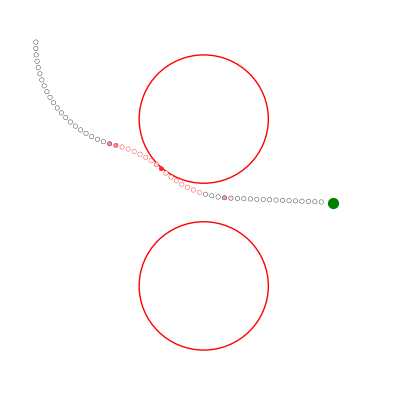

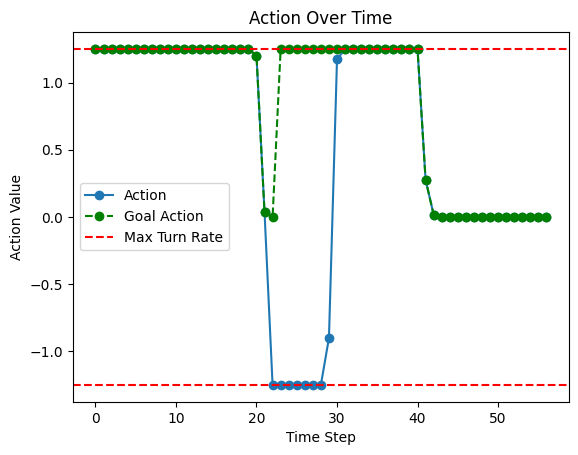

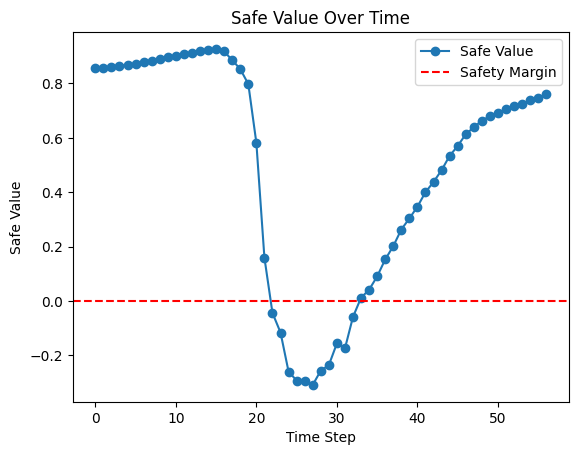

In [26]:
dubin_env = DubinEnv(start_state=np.array([-1.3, 1.3, -np.pi/2]),
                     goal_state=np.array([1, 0, 0.0]))

brt = LatentDubinGapNoGP()

priv_states = []
actions = []
goal_actions = []
current_safe = []
safe_values = []

epsilon = 0.2
simlen = 1000

demo, priv_state = dubin_env.forward(0) # initialize with zero action
feat = brt.data_to_feat(demo)           # render state (took another step in wm)
Vz = brt.evaluate_V(to_np(feat))[0]
Lz = brt.margin_fn(feat)[0][0][0]
safe_value = np.min([Vz, to_np(Lz)])  
demo, priv_state = dubin_env.forward(0) # take real step to match wm step
dubin_env.curr_state = priv_state       # take another step in real
# at this point, Vz should indicate value of current state 

for i in range(simlen):
    # get goal reference direction and action
    goal_dir, goal_act = dubin_env.goal_ref()    
    curr_safe = 1 

    if safe_value < epsilon: 
        safe_action = brt.find_a(feat.detach().cpu().numpy())
        action = safe_action[0]
        curr_safe = 0 # when safe action is engaged
        print(Fore.RED + 'Safe action engaged!' + Style.RESET_ALL)
    else:
        action = goal_act # nominal action otherwise
    
    priv_states.append(priv_state)
    actions.append(action)
    goal_actions.append(goal_act)
    current_safe.append(curr_safe)
    
    feat = brt.data_to_feat(demo, action=action) # take action in wm
    demo, priv_state = dubin_env.forward(action) # take action in real
    Vz = brt.evaluate_V(to_np(feat))[0] # Vz after action
    Lz = brt.margin_fn(feat)[0][0][0]
    safe_value = np.min([Vz, to_np(Lz)])   
    dubin_env.curr_state = priv_state  # update state after taking action
    
    safe_values.append(safe_value)
    distance = np.linalg.norm(dubin_env.goal_state[:2] - dubin_env.curr_state[:2])

    print(f"Step {i+1}: Pstate: {np.round(priv_state,2)}, "
          f"Goal: {np.round(goal_dir,2)}, "
          f"Action: {np.around(action,2)}, "
          f"Dist: {np.round(distance,2)}, "
          f"Safe Value: {np.round(safe_value, 3)}")
    
    if distance < 0.05:
        print("Reached the goal!")
        break

# plot: black edge for trajectory points, red for intervention
# plot: white to red gradient for delta action magnitude
delta_action = np.abs(np.diff(np.array(actions), prepend=actions[0]))
colors = ["white", "red"]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("white_red", colors)
norm = mcolors.Normalize(vmin=0, vmax=u_max - u_min)

# plot the trajectory history and circle obstacle 
fig,ax = plt.subplots()
# hardcoded with existing limits
sf = 1 # scale factor
plt.xlim([sf*brt.args.x_min, sf*brt.args.x_max])
plt.ylim([sf*brt.args.y_min, sf*brt.args.y_max])
plt.axis('off')
fig.set_size_inches(5, 5)
pss = np.array(priv_states)
for x_obs, y_obs, r_obs in zip(brt.args.obs_x, brt.args.obs_y, brt.args.obs_r):
    circle = patches.Circle((x_obs, y_obs), r_obs, edgecolor=(1,0,0), facecolor='none')
    ax.add_patch(circle)
safe_action_idx = np.where(np.array(current_safe) == 1)
unsafe_action_idx = np.where(np.array(current_safe) == 0)
plt.scatter(pss[safe_action_idx][:,0], pss[safe_action_idx][:,1], c=delta_action[safe_action_idx], s=10, label='Trajectory', cmap=custom_cmap, norm=norm, linewidths=0.25, edgecolor='black')
plt.scatter(pss[unsafe_action_idx][:,0], pss[unsafe_action_idx][:,1], c=delta_action[unsafe_action_idx], s=10, label='Trajectory', cmap=custom_cmap, norm=norm, linewidths=0.25, edgecolor='red')
plt.scatter(dubin_env.goal_state[0], dubin_env.goal_state[1], c='green', s=50, label='Goal')

# plot action over time
plt.figure()
plt.plot(np.array(actions), label='Action', marker='o')
plt.plot(np.array(goal_actions), label='Goal Action', marker='o', linestyle='--', color='green')
plt.axhline(y=dubin_env.args.turnRate, color='r', linestyle='--', label='Max Turn Rate')
plt.axhline(y=-dubin_env.args.turnRate, color='r', linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('Action Value')
plt.title('Action Over Time')
plt.legend()
plt.show()
    
plt.figure()
plt.plot(safe_values, label='Safe Value', marker='o')
plt.axhline(y=0, color='r', linestyle='--', label='Safety Margin')
plt.xlabel('Time Step')
plt.ylabel('Safe Value')
plt.title('Safe Value Over Time')
plt.legend()
plt.show()

